# Layer 3 (PFF): checking the StatsBomb LSTM against PFF tracking

This notebook asks whether the LSTM's predicted positions are accurate. So far the LSTM has been scored against the StatsBomb 360 freeze frame: where StatsBomb places the teammate at the moment of the pass. That is also the data the LSTM's history was built from. PFF gives a second, independent view of the same moment, from a different tracking provider, with every player identified.

This notebook:

1. identifies each freeze-frame teammate at every linked World Cup pass with a PFF player, at the same moment;
2. checks which of them PFF actually tracked on camera (VISIBLE) and which it estimated;
3. measures how closely the two providers agree on where the same player is. This sets a floor: no prediction can be checked more precisely than the two sources agree with each other;
4. rebuilds the cross-fitted LSTM predictions for the World Cup matches and scores them against PFF, next to the last-position baseline.

It uses the links saved by `08_layer3_pff_link.ipynb` and the cross-fitted LSTM models saved by `05_layer3_lstm_training.ipynb`. Nothing is retrained.

All positions are in StatsBomb yards with the passing team attacking toward x = 120. Errors are reported in metres (1 yd = 0.9144 m), as in the LSTM notebooks.

In [1]:
# shared figure settings used in every notebook:
# colours (navy, green, grey and light blue) and one folder for every saved figure
import matplotlib.pyplot as plt
from cycler import cycler
from pathlib import Path
plt.rcParams['axes.prop_cycle'] = cycler(color=['#1E2761', '#2C5F2D', '#9AA0A6', '#7F8FC0'])

FIGURES = Path('../data/results/figures')
FIGURES.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a figure to the shared figures folder, in the same format in every notebook."""
    fig.savefig(FIGURES / name, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"saved {FIGURES / name}")


import sys, os, json, pickle, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join('..', 'src'))
import importlib
import pff
importlib.reload(pff)

RESULTS = Path('../data/results')
DATASET_DIR = Path('../data/lstm_dataset')
YARD_TO_M = 0.9144

links = pd.read_pickle(RESULTS / 'pff_pass_links.pkl')
cands = pd.read_pickle(RESULTS / 'candidates_full.pkl')
cands['match_id'] = cands['match_id'].astype(int)
wc_ids = sorted(links['match_id'].unique())
print(len(wc_ids), 'World Cup matches,', len(links), 'linked passes')

64 World Cup matches, 61635 linked passes


## 1. Who is who: freeze-frame teammates matched to PFF players

For each linked pass, every teammate in the freeze frame (inside or outside the passer's vision cone) is matched one-to-one to the passing team's players in PFF's snapshot of the same pass, passer excluded. The matching minimises the total distance (Hungarian algorithm), and a match needs the two positions within 10 yd. PFF players that no freeze-frame teammate matches are kept too: they are teammates the freeze frame does not show.

The table is saved after the first run, so rerunning the notebook skips this step.

In [2]:
TM_PATH = RESULTS / 'pff_teammates_at_passes.pkl'
if TM_PATH.exists():
    tm = pd.read_pickle(TM_PATH)
    print('loaded saved table')
else:
    t0 = time.time()
    parts = []
    for i, mid in enumerate(wc_ids):
        parts.append(pff.teammates_at_passes(links[links['match_id'] == mid],
                                             cands[cands['match_id'] == mid], max_dist=10.0))
        if (i + 1) % 16 == 0:
            print(f'[{i + 1}/{len(wc_ids)}] {time.time() - t0:.0f}s')
    tm = pd.concat(parts, ignore_index=True)
    tm.to_pickle(TM_PATH)
print(len(tm), 'rows')

[16/64] 23s
[32/64] 43s
[48/64] 64s
[64/64] 86s
365784 rows


In [3]:
ff = tm[tm['in_freeze_frame']]
print(f"{ff['original_event_id'].nunique()} linked passes, {len(ff)} freeze-frame teammates")
print(f"matched to a PFF player within 10 yd: {ff['matched'].mean():.1%}")
d = ff.loc[ff['matched'], 'match_dist_yd'] * YARD_TO_M
print('distance between the two positions (m):',
      d.quantile([0.25, 0.5, 0.75, 0.9]).round(2).to_dict())
print()
print('PFF visibility of matched freeze-frame teammates, by the passer\'s vision cone:')
print(pd.crosstab(ff.loc[ff['matched'], 'visible'].map({True: 'inside cone', False: 'outside cone'}),
                  ff.loc[ff['matched'], 'visibility'], normalize='index').round(3))

35763 linked passes, 235004 freeze-frame teammates
matched to a PFF player within 10 yd: 96.5%
distance between the two positions (m): {0.25: 1.81, 0.5: 2.91, 0.75: 4.39, 0.9: 6.01}

PFF visibility of matched freeze-frame teammates, by the passer's vision cone:
visibility    ESTIMATED  VISIBLE
visible                         
inside cone       0.032    0.968
outside cone      0.037    0.963


**What this shows**

**Almost every freeze-frame teammate is found in PFF.** Over 35763 linked passes and 235004 freeze-frame teammates, 96.5 percent are matched to a PFF player within 10 yd.

The two positions for the same player are a median 2.9 m apart:

| Quarter of matches | Gap |
|---|---|
| A quarter | under 1.8 m |
| Three quarters | under 4.4 m |

Section 2 looks at that gap in detail.

**PFF tracked nearly all of them on camera.** 96.3 percent of the teammates outside the passer's cone, the ones the LSTM predicts, are VISIBLE in PFF. That is close to the 96.8 percent inside the cone. This makes sense: a teammate in the freeze frame is on the broadcast camera by definition. So PFF gives a real, measured check for the LSTM's targets, and almost none of them have to be dropped as estimated.

In [4]:
n_pass = tm['original_event_id'].nunique()
per_pass = tm.groupby('original_event_id').agg(in_frame=('in_freeze_frame', 'sum'))
missing = tm[~tm['in_freeze_frame']]
print(f"teammates in the freeze frame per pass: {per_pass['in_frame'].mean():.2f} (PFF lists 10 besides the passer)")
print(f"PFF teammates with no freeze-frame match per pass: {len(missing) / n_pass:.2f}")
print('their PFF visibility:', missing['visibility'].value_counts(normalize=True).round(3).to_dict())

teammates in the freeze frame per pass: 6.57 (PFF lists 10 besides the passer)
PFF teammates with no freeze-frame match per pass: 3.66
their PFF visibility: {'ESTIMATED': 0.928, 'VISIBLE': 0.072}


**What this shows:** the freeze frame shows 6.57 of the passer's 10 teammates on average. PFF has 3.66 more per pass that no freeze-frame teammate was matched to, and 92.8 percent of those are ESTIMATED in PFF as well.

So the teammates missing from the freeze frame are off camera for PFF too. PFF cannot say where they really were, and neither can StatsBomb. This is a limit of broadcast tracking, not of this project. The LSTM check below is therefore about the teammates both providers could see. For the teammates no camera shows, there is no ground truth in either dataset.

## 2. How closely do the two providers agree?

StatsBomb and PFF both turn broadcast video into pitch positions, independently. Comparing their positions for the same player at the same moment (only where PFF marks the player VISIBLE) shows how precise either can be.

Two checks rule out a mistake in the comparison itself:

- **Speed.** If the two snapshots were taken at slightly different moments, the gap would grow quickly with the player's speed.
- **Coordinate mapping.** If the conversion between the two coordinate systems were off, the best possible linear re-mapping (a stretch, shift and slight rotation fitted to the data) would close much of the gap.

In [5]:
both = ff[ff['matched'] & (ff['visibility'] == 'VISIBLE')].copy()
both['gap_m'] = both['match_dist_yd'] * YARD_TO_M
print(f"{len(both)} teammates seen by both providers")
print(f"gap between StatsBomb 360 and PFF positions: median {both['gap_m'].median():.2f} m, "
      f"mean {both['gap_m'].mean():.2f} m, 90th percentile {both['gap_m'].quantile(0.9):.2f} m")
print()
print('by PFF jersey confidence:')
print(both.groupby('confidence')['gap_m'].agg(['median', 'mean', 'size']).round(2))
print()
print('by player speed (PFF, m/s):')
both['speed_band'] = pd.cut(both['speed'], [0, 2, 4, 6, 15], labels=['0-2', '2-4', '4-6', '6+'])
print(both.groupby('speed_band', observed=True)['gap_m'].agg(['median', 'mean', 'size']).round(2))

# could a better coordinate mapping close the gap? best affine fit from PFF to 360 positions
X = np.c_[both['pff_x'], both['pff_y'], np.ones(len(both))]
bx = np.linalg.lstsq(X, both['cand_x'], rcond=None)[0]
by = np.linalg.lstsq(X, both['cand_y'], rcond=None)[0]
gap_fit = np.hypot(both['cand_x'] - X @ bx, both['cand_y'] - X @ by) * YARD_TO_M
print()
print(f"after the best possible linear re-mapping: median {np.median(gap_fit):.2f} m, mean {gap_fit.mean():.2f} m")
print(f"mean offset (360 minus PFF): x {(both['cand_x'] - both['pff_x']).mean() * YARD_TO_M:+.2f} m, "
      f"y {(both['cand_y'] - both['pff_y']).mean() * YARD_TO_M:+.2f} m")

218819 teammates seen by both providers
gap between StatsBomb 360 and PFF positions: median 2.87 m, mean 3.21 m, 90th percentile 5.90 m

by PFF jersey confidence:
            median  mean    size
confidence                      
HIGH          2.85  3.19  153910
LOW           2.88  3.22   25392
MEDIUM        2.95  3.31   39517

by player speed (PFF, m/s):
            median  mean   size
speed_band                     
0-2           2.82  3.16  52091
2-4           2.91  3.24  28961
4-6           3.01  3.35   6963
6+            3.02  3.35   1092

after the best possible linear re-mapping: median 2.75 m, mean 3.11 m
mean offset (360 minus PFF): x -0.05 m, y +0.03 m


**What this shows**

**The two providers disagree by about 3 m on where the same player is.** For 218819 teammates seen by both, StatsBomb 360 and PFF positions are a median 2.87 m apart (mean 3.21 m; 10 percent are more than 5.90 m apart). These figures are slightly understated, because a match needs the two positions within 10 yd (9.1 m).

**It is not a timing or conversion error.**

- **Not timing.** The gap barely changes with speed: 2.82 m for players under 2 m/s, against 3.02 m above 6 m/s. A timing difference would make fast players far worse.
- **Not the coordinate mapping.** The best possible linear re-mapping only brings the median down to 2.75 m. There is no systematic offset either (the mean difference is under 0.1 m in each direction).
- **Not player identification.** PFF's confidence in the player's identity makes no difference (2.85 to 2.95 m).

So this is measurement noise. Both providers estimate positions from broadcast video, and at least one of them is typically a few metres off.

**Why this matters for RQ3.** The LSTM's mean error against the freeze frame was 3.05 m (cross-fitted, all 166 matches). That is about the same size as the disagreement between two professional tracking providers. Part of what looked like LSTM error is noise in the positions it is scored against.

## 3. Rebuilding the LSTM predictions for the World Cup

The cross-fitted predictions saved earlier store only the error, not the predicted position. This rebuilds the predicted positions with exactly the same models. Each match uses the fold model that never saw it, so every prediction is out-of-sample.

The code below is copied unchanged from `05_layer3_lstm_training.ipynb` (feature building, model and prediction). The first check confirms that the rebuilt predictions reproduce the stored errors.

Needs torch, as in the training notebook.

In [6]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

POS_SCALE = 10.0
TIME_SCALE = 5.0
CF_K = 10


def build_features(hist, target_t, k_max):
    h = hist[:, -k_max:, :]
    n = (~np.isnan(h[:, :, 0])).sum(axis=1)
    last = h[:, -1, :]
    feats = np.zeros((len(h), k_max, 5), dtype=np.float32)
    feats[..., 0] = (h[..., 0] - last[:, None, 0]) / POS_SCALE
    feats[..., 1] = (h[..., 1] - last[:, None, 1]) / POS_SCALE
    feats[..., 2] = h[..., 0] / 120.0
    feats[..., 3] = h[..., 1] / 80.0
    feats[..., 4] = (target_t[:, None] - h[..., 2]) / TIME_SCALE
    feats = np.nan_to_num(feats, nan=0.0)
    idx = (np.arange(k_max)[None, :] + (k_max - n)[:, None]) % k_max
    feats = np.take_along_axis(feats, idx[:, :, None], axis=1)
    return feats, n, last


class TrajectoryLSTM(nn.Module):
    def __init__(self, n_features=5, hidden=64, layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(), nn.Linear(64, 2))

    def forward(self, x, lengths):
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)
        return self.head(h[-1])


def predict(model, X, L, batch_size=8192):
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            xb = torch.from_numpy(X[s:s + batch_size])
            lb = torch.from_numpy(L[s:s + batch_size].astype(np.int64))
            out.append(model(xb, lb).numpy())
    return np.concatenate(out) * POS_SCALE


CF_DIR = RESULTS / 'crossfit'
folds = json.load(open(CF_DIR / 'folds.json'))
fold_of = {str(m): f for f, ids in enumerate(folds) for m in ids}
models = {}
for f in range(len(folds)):
    m = TrajectoryLSTM()
    m.load_state_dict(torch.load(CF_DIR / f'lstm_k{CF_K}_fold{f}.pt', map_location='cpu'))
    models[f] = m

cf = pd.read_pickle(RESULTS / 'rq3_crossfit_predictions.pkl')
cf['match_id'] = cf['match_id'].astype(int)

parts = []
for mid in wc_ids:
    with open(DATASET_DIR / f'match_{mid}.pkl', 'rb') as fh:
        d = pickle.load(fh)
    hist, target, meta = d['eval_hist'], d['eval_target'], d['eval_meta']
    inv = cands[(cands['match_id'] == mid) & (~cands['visible'])]
    assert len(inv) == len(meta) and np.allclose(inv['cand_x'].to_numpy(), meta['cand_x'].to_numpy())
    stored = cf[cf['match_id'] == mid]
    assert len(stored) == len(meta)
    rows = np.flatnonzero(meta['n_hist'].to_numpy() >= 1)
    feats, n, last = build_features(hist[rows], target[rows, 2], CF_K)
    disp = predict(models[fold_of[str(mid)]], feats, n)
    parts.append(pd.DataFrame({
        'cand_index': inv.index[rows],
        'n_hist': meta['n_hist'].to_numpy()[rows],
        'horizon_s': target[rows, 2] - hist[rows, -1, 2],
        'last_x': last[:, 0], 'last_y': last[:, 1],
        'lstm_x': last[:, 0] + disp[:, 0], 'lstm_y': last[:, 1] + disp[:, 1],
        'stored_err_lstm_m': stored['err_lstm_m'].to_numpy()[rows],
    }))
preds = pd.concat(parts, ignore_index=True)

c = cands.loc[preds['cand_index']]
rebuilt = np.hypot(preds['lstm_x'].to_numpy() - c['cand_x'].to_numpy(),
                   preds['lstm_y'].to_numpy() - c['cand_y'].to_numpy()) * YARD_TO_M
print(f'{len(preds)} invisible teammates with at least one earlier point')
print(f"largest difference from the stored cross-fitted errors: {np.nanmax(np.abs(rebuilt - preds['stored_err_lstm_m'])):.2e} m")

102103 invisible teammates with at least one earlier point
largest difference from the stored cross-fitted errors: 5.00e-06 m


**What this shows:** the rebuilt predictions reproduce the stored cross-fitted errors to within 0.000005 m, which is rounding. So these are exactly the predictions behind the RQ3 and RQ2 results. Of the World Cup's invisible teammates, 102103 have at least one earlier point and therefore an LSTM prediction.

## 4. LSTM accuracy against PFF

Scored on the teammates outside the passer's cone who have at least one earlier point, and whom PFF tracked on camera (VISIBLE) at the moment of the pass. Each method's error is measured against both truths:

- **against 360:** the freeze-frame position, as in the LSTM notebooks;
- **against PFF:** PFF's tracked position for the same player.

The gap between the two providers for the same teammates is shown alongside as the measurement floor. The match bootstrap (5000 resamples of whole matches) tests whether the LSTM still beats last position when judged by PFF.

In [7]:
ev = tm[tm['in_freeze_frame'] & tm['matched'] & (tm['visibility'] == 'VISIBLE')]
ev = ev.merge(preds, on='cand_index')
for name in ['last', 'lstm']:
    ev[f'err_{name}_360'] = np.hypot(ev[f'{name}_x'] - ev['cand_x'], ev[f'{name}_y'] - ev['cand_y']) * YARD_TO_M
    ev[f'err_{name}_pff'] = np.hypot(ev[f'{name}_x'] - ev['pff_x'], ev[f'{name}_y'] - ev['pff_y']) * YARD_TO_M
ev['gap_m'] = ev['match_dist_yd'] * YARD_TO_M
print(f"{len(ev)} teammates outside the cone, with history, tracked by PFF")

summary = pd.DataFrame({
    'last position vs 360': ev['err_last_360'],
    'LSTM vs 360': ev['err_lstm_360'],
    'last position vs PFF': ev['err_last_pff'],
    'LSTM vs PFF': ev['err_lstm_pff'],
    '360 vs PFF (floor)': ev['gap_m'],
}).describe(percentiles=[0.5, 0.9]).T[['mean', '50%', '90%']].round(3)
print(summary)


def match_bootstrap(df, worse, better, n_boot=5000, seed=0):
    g = df.groupby('match_id').agg(w=(worse, 'sum'), b=(better, 'sum'), n=(worse, 'size'))
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(g), size=(n_boot, len(g)))
    w, b, n = g['w'].to_numpy()[idx].sum(1), g['b'].to_numpy()[idx].sum(1), g['n'].to_numpy()[idx].sum(1)
    gain = (w - b) / n
    point = (g['w'].sum() - g['b'].sum()) / g['n'].sum()
    wins = ((g['w'] - g['b']) > 0).sum()
    return pd.Series({'gain_m': point, 'ci_low': np.percentile(gain, 2.5), 'ci_high': np.percentile(gain, 97.5),
                      'matches_lstm_better': f'{wins}/{len(g)}'})

print()
print(pd.DataFrame({
    'judged by 360': match_bootstrap(ev, 'err_last_360', 'err_lstm_360'),
    'judged by PFF': match_bootstrap(ev, 'err_last_pff', 'err_lstm_pff'),
}).T)

92847 teammates outside the cone, with history, tracked by PFF
                       mean    50%    90%
last position vs 360  3.213  2.657  6.270
LSTM vs 360           3.098  2.568  6.019
last position vs PFF  4.082  3.635  7.373
LSTM vs PFF           4.039  3.596  7.277
360 vs PFF (floor)    3.158  2.830  5.765

                 gain_m    ci_low   ci_high matches_lstm_better
judged by 360  0.115121  0.101538  0.128801               63/64
judged by PFF   0.04385  0.033419  0.054799               55/64


**What this shows**

The check covers 92847 teammates outside the cone who have an earlier point and whom PFF tracked on camera.

**Against an independent tracker, the LSTM is out by about 4 m on average.**

| | Mean error | Median error |
|---|---|---|
| LSTM vs PFF | 4.04 m | 3.60 m |
| LSTM vs 360 | 3.10 m | 2.57 m |
| 360 vs PFF, same teammates | 3.16 m | 2.83 m |

Most of that 4 m is the disagreement between the providers themselves. Scoring against PFF is harsher than scoring against 360 for a simple reason. The LSTM's history and its 360 target come from the same provider, so that provider's errors partly cancel. PFF's errors do not. That is also why the LSTM agrees with 360 more closely (median 2.57 m) than PFF does (2.83 m).

**The LSTM still beats last position when judged by PFF, but by less.**

| Judged by | LSTM gain | 95% CI | Matches where the LSTM wins |
|---|---|---|---|
| 360 | 0.115 m | 0.102 to 0.129 | 63 of 64 |
| PFF | 0.044 m | 0.033 to 0.055 | 55 of 64 |

The interval stays clear of zero, so the LSTM's advantage is real against an independent tracker. It is small, though: about 4 cm on positions that are uncertain by about 3 m. Part of what the LSTM learned over last position was how StatsBomb's own positions behave, not only how players move.

**Are the predicted positions accurate?** the predicted positions are accurate to about the precision the data allows. Against an independent tracker they are within 3.6 m half the time. That is less than 1 m worse than the two trackers agree with each other.

**Memory feasibility under the independent truth.** A teammate was called memory-feasible when the LSTM's prediction was within 4 m of the freeze-frame position. This checks how many of those are also within 4 m of PFF's position, and how the feasible share of these teammates changes when PFF is the truth.

In [8]:
TAU = 4.0
ev['feasible_360'] = ev['err_lstm_360'] < TAU
ev['feasible_pff'] = ev['err_lstm_pff'] < TAU
print(f"memory-feasible by 360: {ev['feasible_360'].mean():.1%};  by PFF: {ev['feasible_pff'].mean():.1%}")
print(f"of those feasible by 360, also feasible by PFF: {ev.loc[ev['feasible_360'], 'feasible_pff'].mean():.1%}")
print(f"labels agree: {(ev['feasible_360'] == ev['feasible_pff']).mean():.1%}")
print()
for tau in [3.0, 4.0, 5.0]:
    print(f"tau = {tau:.0f} m: feasible by 360 {(ev['err_lstm_360'] < tau).mean():.1%}, by PFF {(ev['err_lstm_pff'] < tau).mean():.1%}")

memory-feasible by 360: 73.8%;  by PFF: 56.8%
of those feasible by 360, also feasible by PFF: 66.1%
labels agree: 66.9%

tau = 3 m: feasible by 360 58.4%, by PFF 39.4%
tau = 4 m: feasible by 360 73.8%, by PFF 56.8%
tau = 5 m: feasible by 360 83.5%, by PFF 71.0%


**What this shows**

**The memory-feasible label is sensitive to which tracker is the truth.** With PFF as the truth, the share of these teammates within 4 m falls from 73.8 to 56.8 percent. Only 66.1 percent of those feasible by 360 are also feasible by PFF, and the labels agree for 66.9 percent of teammates. The drop is similar at every threshold:

| Threshold | Feasible by 360 | Feasible by PFF |
|---|---|---|
| 3 m | 58.4% | 39.4% |
| 4 m | 73.8% | 56.8% |
| 5 m | 83.5% | 71.0% |

The reason is the measurement floor. A 4 m threshold is close to the size of the disagreement between providers, so many teammates sit near the line and move across it depending on the truth used.

**What it means for the RQ3 results.** The three-way RQ2 split and the blind-pass test both used the 360-based label. A noisy label makes groups more alike than they really are. So the "no difference between memory-feasible and infeasible teammates" findings could be partly a dilution effect. The PFF version of RQ3 (`13_layer3_pff_rq3_answer.ipynb`) reruns the blind-pass test with memory defined from the passer's own cone and real player identities, and finds that blind-pass receivers are more often memory-feasible than other unseen teammates.

## 5. Figure: LSTM error and the measurement floor

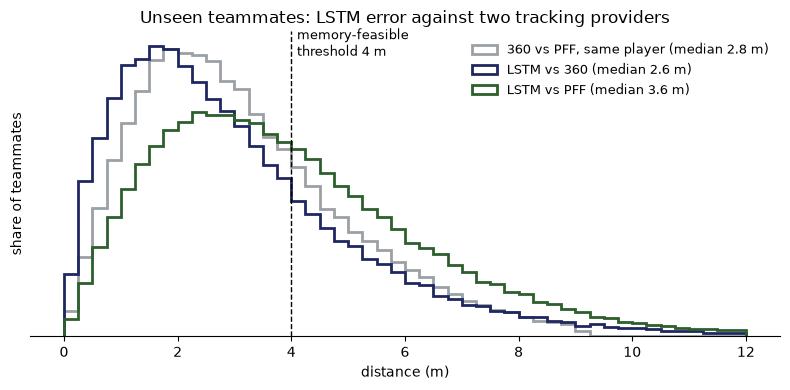

In [9]:
NAVY, GREEN, GREY = '#1E2761', '#2C5F2D', '#9AA0A6'
bins = np.arange(0, 12.25, 0.25)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ev['gap_m'], bins=bins, histtype='step', lw=2, color=GREY, density=True,
        label=f"360 vs PFF, same player (median {ev['gap_m'].median():.1f} m)")
ax.hist(ev['err_lstm_360'], bins=bins, histtype='step', lw=2, color=NAVY, density=True,
        label=f"LSTM vs 360 (median {ev['err_lstm_360'].median():.1f} m)")
ax.hist(ev['err_lstm_pff'], bins=bins, histtype='step', lw=2, color=GREEN, density=True,
        label=f"LSTM vs PFF (median {ev['err_lstm_pff'].median():.1f} m)")
ax.axvline(4.0, color='black', ls='--', lw=1)
ax.text(4.1, ax.get_ylim()[1] * 0.92, 'memory-feasible\nthreshold 4 m', fontsize=9)
ax.set_xlabel('distance (m)')
ax.set_ylabel('share of teammates')
ax.set_yticks([])
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.legend(frameon=False, fontsize=9)
ax.set_title('Unseen teammates: LSTM error against two tracking providers')
plt.tight_layout()
save_fig(plt.gcf(), 'rq3_pff_lstm_check.png')
plt.show()

## 6. Save

In [10]:
ev.to_pickle(RESULTS / 'rq3_lstm_vs_pff.pkl')
print('saved', len(ev), 'rows to rq3_lstm_vs_pff.pkl (pff_teammates_at_passes.pkl saved in section 1)')

saved 92847 rows to rq3_lstm_vs_pff.pkl (pff_teammates_at_passes.pkl saved in section 1)


## Summary

**Are the predicted positions accurate?**

**Ground truth exists for the LSTM's targets.**

- PFF identifies 96.5 percent of freeze-frame teammates at 35763 World Cup passes.
- 96.3 percent of those outside the passer's cone are tracked on camera, so there is a measured position to check against.
- The teammates missing from the freeze frame (3.66 per pass) are estimated by PFF too. Nobody knows where off-camera players were, so they cannot be checked in either dataset.

**The data has a measurement floor of about 3 m.** StatsBomb 360 and PFF place the same player a median 2.87 m apart. This is not a timing, coordinate or identity problem. It is the precision of broadcast tracking.

**The LSTM is about as accurate as that floor allows.**

- Against PFF, an independent tracker, its mean error is 4.04 m (median 3.60 m), less than 1 m above the providers' own disagreement on the same teammates.
- It still beats last position against PFF: 0.044 m, 95 percent CI 0.033 to 0.055, better in 55 of 64 matches. The gain is much smaller than against 360 (0.115 m).

**The 4 m memory-feasibility threshold is close to the noise level.**

- Judged by PFF, 56.8 percent rather than 73.8 percent of these teammates are memory-feasible, and the two labels agree for 66.9 percent.
- Group comparisons that rely on this label are therefore diluted. The PFF version of RQ3 redoes the blind-pass test with a stricter, PFF-based definition of memory.

Saved: `pff_teammates_at_passes.pkl`, `rq3_lstm_vs_pff.pkl`, `figures/rq3_pff_lstm_check.png`.

**Next:** whether a pass to the predicted position could actually arrive, using the PFF tracking around each pass (`10_layer3_pff_reachability.ipynb`).